<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>


#### Import the required libraries we need for the lab.


In [1]:
%pip install seaborn
#pip install numpy

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

Matplotlib is building the font cache; this may take a moment.


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

In [5]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


#### Add your code below following the instructions given in the course to complete the peer graded assignment


### Task 2: Generate Descriptive Statistics and Visualizations


##### 1. For the "Median value of owner-occupied homes" provide a boxplot ###

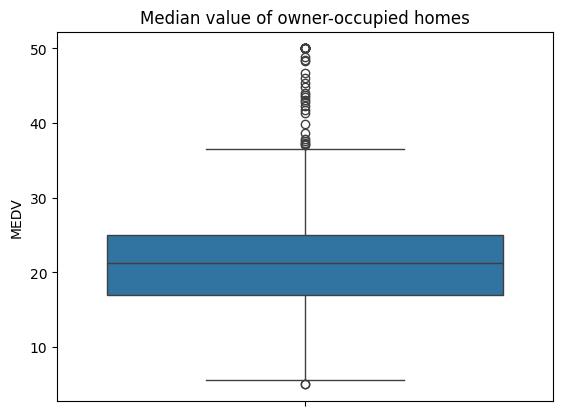

In [6]:
plot_1 = sns.boxplot(y='MEDV', data=boston_df)
plot_1.set_title('Median value of owner-occupied homes') 
plt.show()

The boxplot gives information about the variable 'MEDV' including median, first quartile, third quartile, minimum, maximum abd also outlier.

##### 2. Provide a  bar plot for the Charles river variable

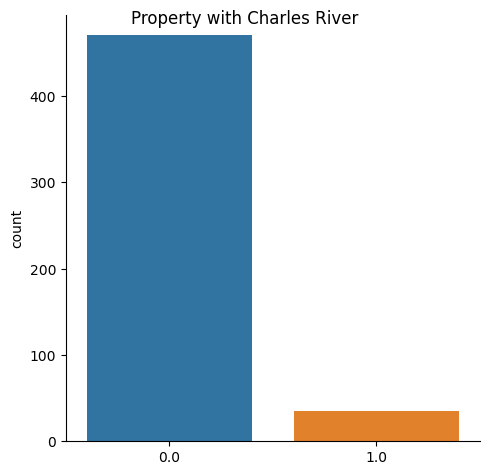

In [7]:
plot_2 = sns.catplot(x='CHAS', kind='count', data=boston_df, hue = 'CHAS', legend=False)
plot_2.set_axis_labels(x_var='')
plot_2.fig.suptitle('Property with Charles River')
plt.show()

The bar chart gives the number of property located near versus far from the Charles River

##### 3. Provide a boxplot for the MEDV variable vs the AGE variable. (Discretize the age variable into three groups of 35 years and younger, between 35 and 70 years and 70 years and older)

In [8]:
#Categorize the age group
boston_df.loc[(boston_df['AGE'] <= 35), 'AGE_GROUP'] = '35 years and younger'
boston_df.loc[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70), 'AGE_GROUP'] = 'between 35 and 70 years'
boston_df.loc[(boston_df['AGE'] >= 70), 'AGE_GROUP'] = '70 years and older'

In [9]:
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,AGE_GROUP
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0,between 35 and 70 years
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6,70 years and older
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7,between 35 and 70 years
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4,between 35 and 70 years
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2,between 35 and 70 years


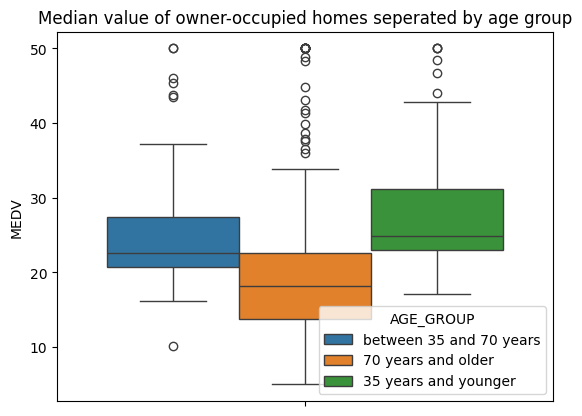

In [10]:
plot_3 = sns.boxplot(y="MEDV", hue="AGE_GROUP", data=boston_df)
plot_3.set_title('Median value of owner-occupied homes seperated by age group') 
plt.show()

##### 4. Provide a scatter plot to show the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town. What can you say about the relationship?

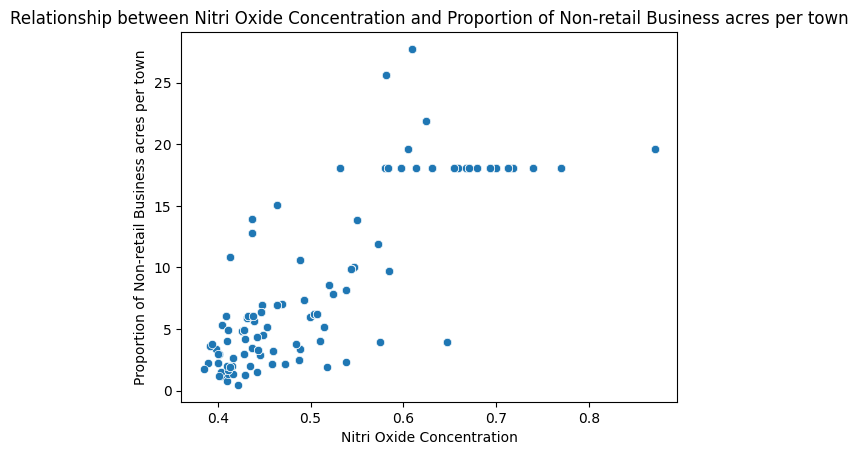

In [11]:
plot_4 = sns.scatterplot(x='NOX', y='INDUS', data=boston_df)
plot_4.set_title('Relationship between Nitri Oxide Concentration and Proportion of Non-retail Business acres per town')
plt.xlabel('Nitri Oxide Concentration')
plt.ylabel('Proportion of Non-retail Business acres per town')
plt.show()

The graph shows that as the concentration of nitric oxides increases, the proportion of non-retail business acres per town also increases.

##### 5. Create a histogram for the pupil to teacher ratio variable

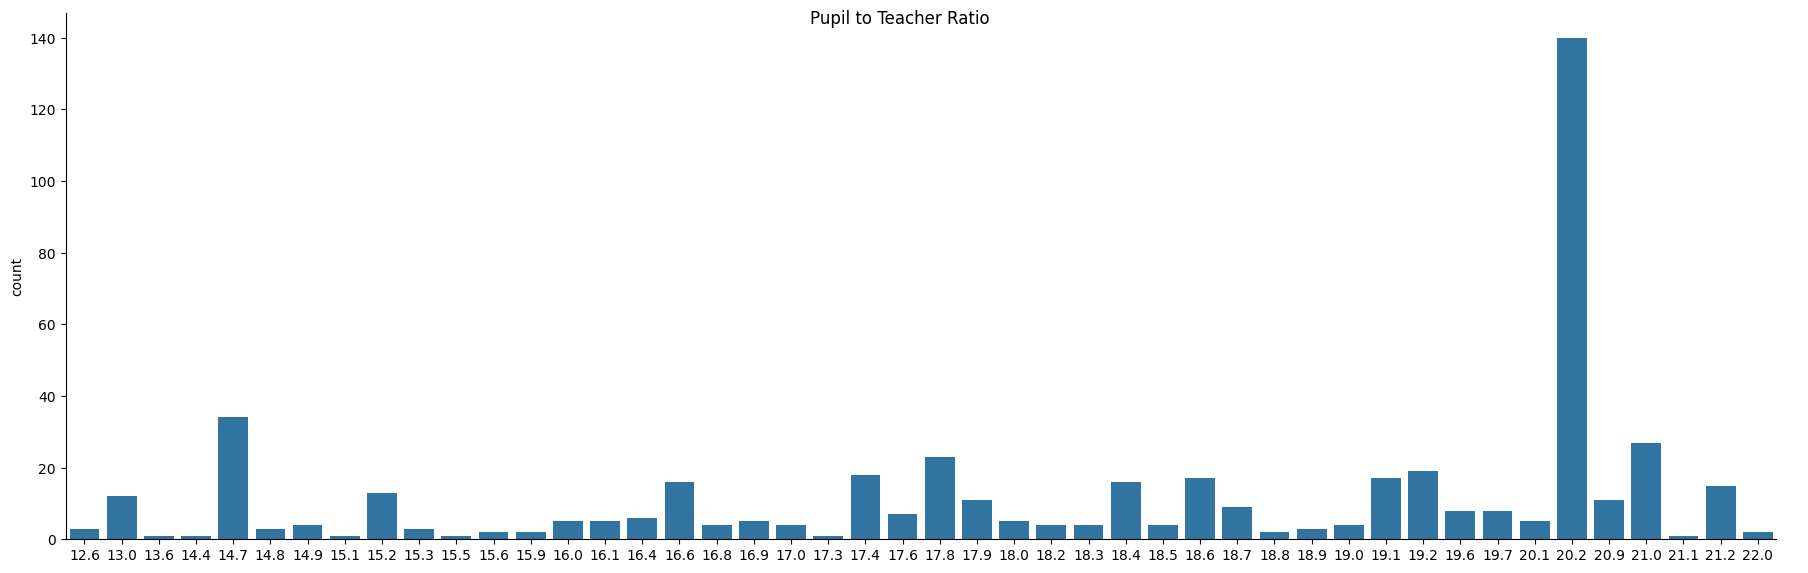

In [12]:
plot_5 = sns.catplot(x='PTRATIO', kind='count', data=boston_df, height = 6, aspect = 3) 
plot_5.set_axis_labels(x_var='')
plot_5.fig.suptitle('Pupil to Teacher Ratio')
plt.show()

According to the histogram, the most common pupil-to-teacher ratio is 20.2.

### Task 3: Statistical Testing

##### Q1: Is there a significant difference in the median value of houses bounded by the Charles river or not?

State the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ("there is no difference in median value of houses bounded by the Charles river")
*   $H\_1: µ\_1 ≠ µ\_2$ ("there is a difference in median value of houses bounded by the Charles river")

With α = 0.05

In [13]:
# use the Levene's Test in Python to check test significance
scipy.stats.levene(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], center='mean')

LeveneResult(statistic=np.float64(8.75190489604598), pvalue=np.float64(0.003238119367639829))

The p value is lower than 0.05, we assume that the variance is not equal.

In [14]:
#T-Test
scipy.stats.ttest_ind(boston_df[boston_df['CHAS'] == 0]['MEDV'],
                   boston_df[boston_df['CHAS'] == 1]['MEDV'], equal_var = False)

TtestResult(statistic=np.float64(-3.113291312794837), pvalue=np.float64(0.0035671700981375174), df=np.float64(36.876408797611994))

The p-value is lower than 0.05, We reject the null hypothesis. So, there is a difference in median value of houses bounded by the Charles river.

##### Q2: Is there a difference in Median values of houses (MEDV) for each proportion of owner occupied units built prior to 1940 (AGE)? 

State the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ("there is no difference in median value of houses for each proportion of owner occupied units built prior to 1940")
*   $H\_1: µ\_1 ≠ µ\_2$ ("there is a difference in median value of houses for each proportion of owner occupied units built prior to 1940")

With α = 0.05

In [15]:
#Medthod 1: Hypothesis Testing

young = boston_df[boston_df['AGE_GROUP'] == '35 years and younger']['MEDV']
moderate = boston_df[boston_df['AGE_GROUP'] == 'between 35 and 70 years']['MEDV']
old = boston_df[boston_df['AGE_GROUP'] == '70 years and older']['MEDV']

In [16]:
f_statistic, p_value = scipy.stats.f_oneway(young, moderate, old)
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))

F_Statistic: 36.40764999196599, P-Value: 1.7105011022702984e-15


In [17]:
#Method 2: Regression with ANOVA
from statsmodels.formula.api import ols
lm = ols('MEDV ~ AGE_GROUP', data = boston_df).fit()
table= sm.stats.anova_lm(lm)
print(table)

              df        sum_sq      mean_sq         F        PR(>F)
AGE_GROUP    2.0   5401.731883  2700.865942  36.40765  1.710501e-15
Residual   503.0  37314.563532    74.184023       NaN           NaN


The p-value is lower than 0.05, We reject the null hypothesis. So, there is a difference in median value of houses for each proportion of owner occupied units built prior to 1940.

##### Q3: Can we conclude that there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town?

State the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ("there is no relationship between Nitric oxide concentrations and proportion of non-retail business acres per town")
*   $H\_1: µ\_1 ≠ µ\_2$ ("there is a relationship between Nitric oxide concentrations and proportion of non-retail business acres per town")

With α = 0.05

In [18]:
# Method1: pearson r
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=np.float64(0.763651446920915), pvalue=np.float64(7.913361061241112e-98))

In [19]:
# Method2: Regression Model

## X is the input variables (or independent variables)
X = boston_df['NOX']
## y is the target/dependent variable
y = boston_df['INDUS']
## add an intercept (beta_0) to our model
X = sm.add_constant(X) 

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Print out the statistics
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  INDUS   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     705.1
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           7.91e-98
Time:                        14:24:04   Log-Likelihood:                -1470.5
No. Observations:                 506   AIC:                             2945.
Df Residuals:                     504   BIC:                             2954.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -13.9414      0.965    -14.450      0.000     -15.837     -12.046
NOX           45.2108      1.703     26.554      0.000      41.866      48.556
==============================================================================
Omnibus:                       46.050   Durbin-Watson:                   0.272
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.622
Skew:                           0.649   Prob(JB):                     2.07e-15
Kurtosis:                       4.233   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The p-value is lower than 0.05, We reject the null hypothesis. So, there is a relationship between Nitric oxide concentrations and proportion of non-retail business acres per town.

##### Q4: What is the impact of an additional weighted distance  to the five Boston employment centres on the median value of owner occupied homes? 

State the hypothesis

*   $H\_0: µ\_1 = µ\_2$ ("there is no relationship between an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes")
*   $H\_1: µ\_1 ≠ µ\_2$ ("there is a relationship between an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes")

With α = 0.05

In [20]:
## X is the input variables (or independent variables)
X2 = boston_df['DIS']
## y is the target/dependent variable
y2 = boston_df['MEDV']
## add an intercept (beta_0) to our model
X2 = sm.add_constant(X2) 

model_2 = sm.OLS(y2, X2).fit()
predictions_2 = model_2.predict(X)

# Print out the statistics
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.21e-08
Time:                        14:24:06   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The p-value is lower than 0.05, We reject the null hypothesis. So, there is a relationship between an additional weighted distance to the five Boston employment centres on the median value of owner occupied homes.

As the coefficient value is 0.249, indicating there is a slightly correlation between distance to the five Boston employment centres and the median value of owner occupied homes.